# Linear State-Space Baseline

Goal: model subsystem dynamics with a simple linear transition model.

State update model:

x(t+1) = A x(t)

Residual innovation:

r(t) = x(t+1) − A x(t)

The squared residual energy is used as the anomaly score.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

## Load Continuous Normalized Data
Note:
All sequences are normalized using statistics computed from the training split.
Shape:
(num_timesteps, num_sensors)

In [2]:
X_train = np.load("data/X_train_raw.npy")
X_val   = np.load("data/X_val_raw.npy")
X_test  = np.load("data/X_test_raw.npy")

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (1244, 12)
Val shape: (415, 12)
Test shape: (415, 12)


## Estimate Transition Matrix

The linear transition matrix A is estimated using least squares:

X(t+1) ≈ A X(t)

In [3]:
# Shifted matrices
X_t  = X_train[:-1]
X_t1 = X_train[1:]

# Least squares solution
A, _, _, _ = np.linalg.lstsq(X_t, X_t1, rcond=None)

print("Transition matrix shape:", A.shape)

Transition matrix shape: (12, 12)


## Compute Innovation Residual Energy

In [4]:
def compute_residual_energy(sequence, A):
    residuals = []
    
    for t in range(len(sequence) - 1):
        x_pred = sequence[t] @ A
        r = sequence[t+1] - x_pred
        
        # Squared residual energy
        energy = np.sum(r**2)
        residuals.append(energy)
    
    return np.array(residuals)

In [5]:
train_residuals = compute_residual_energy(X_train, A)
val_residuals   = compute_residual_energy(X_val, A)
test_residuals  = compute_residual_energy(X_test, A)

## Threshold from Validation Residuals

In [6]:
threshold = np.percentile(val_residuals, 95)

print("Residual threshold:", threshold)

Residual threshold: 45.19562497771508


In [7]:
## Detect Anomalous Transitions

In [8]:
kalman_anomalies = test_residuals > threshold

print("Kalman-style anomalies detected:", kalman_anomalies.sum())

Kalman-style anomalies detected: 23


## Visualization

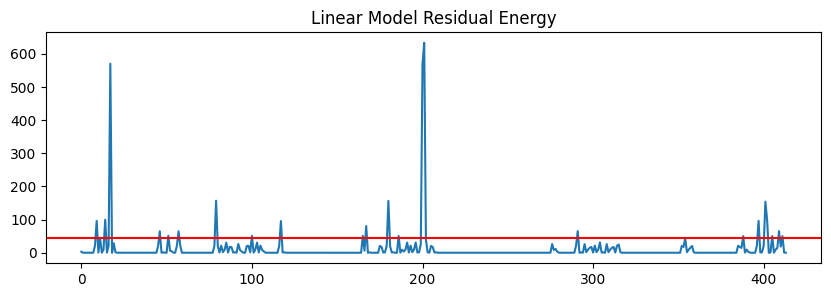

In [9]:
plt.figure(figsize=(10,3))
plt.plot(test_residuals)
plt.axhline(threshold, color="red")
plt.title("Linear Model Residual Energy")
plt.show()

## Observations

The linear model captures simple system dynamics.

Large residual energy appears when the observed transition
deviates from the learned linear dynamics.

This provides a simple physics-inspired anomaly signal.

In [10]:
lstm_test_scores = np.load("data/lstm_test_scores.npy")
lstm_anomalies   = np.load("data/lstm_anomalies.npy")

print("LSTM anomalies:", lstm_anomalies.sum())
print("Linear anomalies:", kalman_anomalies.sum())

LSTM anomalies: 2
Linear anomalies: 23


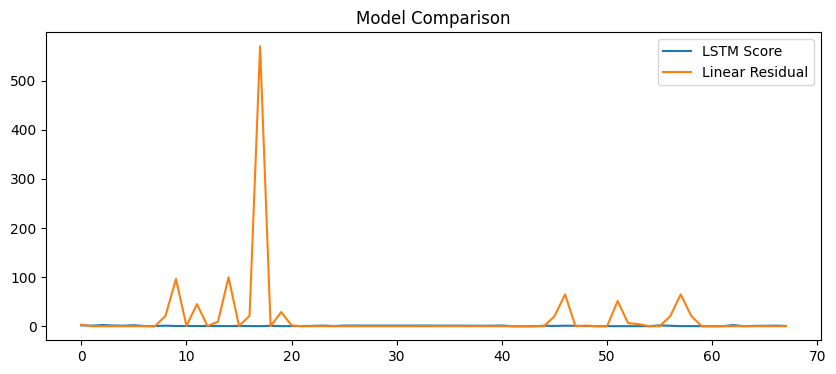

In [11]:
plt.figure(figsize=(10,4))
plt.plot(lstm_test_scores, label="LSTM Score")
plt.plot(test_residuals[:len(lstm_test_scores)], label="Linear Residual")
plt.legend()
plt.title("Model Comparison")
plt.show()

## Model Comparison

The linear transition model detects several anomalous transitions
that are not flagged by the LSTM.

This suggests the two approaches respond to different types of
system behavior:

• Linear residuals react strongly to local transition deviations  
• The LSTM model captures broader temporal context  

The disagreement between detectors indicates complementary behavior.

Next step: decompose residual energy by sensor to identify which
telemetry channels contribute most during anomalous transitions.

Future work: Investigate residual contributions per sensor to perform root cause attribution.

In [12]:
np.save("data/linear_A.npy", A)